##LastUpdateOstatnia zmiana:  08.04.26

import bazy danych z OVH
puszczenie modeli
export bazy do ovh
zamknięcie połączenia


# Moduł 0: Konfiguracja + import bazy

## libraries

zastąp kopiowanie bazy selectami

In [1]:
# redund do wyrzucenia
!pip install paramiko

import paramiko
import duckdb
import os
import datetime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.9/208.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.0/161.0 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 48.7 MB/s eta 0:00:00


In [3]:
# ============================================
# MODUŁ 0: KONFIGURACJA
# ============================================

# Parametr losowości dla modeli
RANDOM_SEED = 42

# Zakres prognozy
FORECAST_START = None
FORECAST_END   = None

# Czy zapisywać raport do Excela
SAVE_EXCEL = True

# Katalog wyjściowy
OUTPUT_DIR = "."

# Nazwy arkuszy raportu
#SHEET_DT_PRICES     = "DT_prices"
#SHEET_RF_PRICES     = "RF_prices"
#SHEET_ARIMAX_PRICES = "ARIMAX_prices"
#SHEET_RESIDUAL_LOAD = "Residual_load"

# Ile tygodni historii pokazać w raporcie
HISTORY_WEEKS = 2

In [4]:
# nowa procedura do testowania
# wyrzucić te gdzie jest redundancja

# ============================================
# MODUŁ 01 — MASTER CONNECT (RESET + DOWNLOAD + CONNECT)
# ============================================


# --- KONFIG ---
VPS_HOST = "51.254.131.14"
VPS_PORT = 22
VPS_USER = "ubuntu"
VPS_PASSWORD = "ModestAmaro77#"

REMOTE_DB_PATH = "/home/ubuntu/db/forecast_db.duckdb"
LOCAL_DB_PATH = "/content/forecast_db.duckdb"

print("[INFO] START MASTER CONNECT")

# ============================================
# 1️⃣ ZAMKNIĘCIE STAREGO POŁĄCZENIA
# ============================================
try:
    con.close()
    print("[OK] Zamknięto stare połączenie")
except:
    print("[INFO] Brak aktywnego połączenia")

# ============================================
# 2️⃣ USUNIĘCIE LOKALNEGO PLIKU (ANTI-CACHE)
# ============================================
if os.path.exists(LOCAL_DB_PATH):
    os.remove(LOCAL_DB_PATH)
    print("[OK] Usunięto lokalną bazę (anti-cache)")

# ============================================
# 3️⃣ DOWNLOAD Z OVH
# ============================================
print("[INFO] Pobieranie bazy z OVH...")

transport = paramiko.Transport((VPS_HOST, VPS_PORT))
transport.connect(username=VPS_USER, password=VPS_PASSWORD)

sftp = paramiko.SFTPClient.from_transport(transport)
sftp.get(REMOTE_DB_PATH, LOCAL_DB_PATH)

sftp.close()
transport.close()

print("[OK] Baza pobrana")

# ============================================
# 4️⃣ WALIDACJA PLIKU
# ============================================
if not os.path.exists(LOCAL_DB_PATH):
    raise FileNotFoundError("[ERROR] Brak pliku DB po downloadzie")

file_size = os.path.getsize(LOCAL_DB_PATH)
ts = os.path.getmtime(LOCAL_DB_PATH)
last_update = datetime.datetime.fromtimestamp(ts)

print(f"[INFO] Size: {file_size} bytes")
print(f"[INFO] Last update: {last_update}")

# ============================================
# 5️⃣ CONNECT DUCKDB
# ============================================
con = duckdb.connect(LOCAL_DB_PATH, read_only=False)

print("[OK] Połączono z DuckDB")

# ============================================
# 6️⃣ SANITY CHECK
# ============================================

# --- lista tabel ---
tables = con.execute("SHOW TABLES").fetchall()
print("[INFO] Tabele:", tables)

# --- kluczowy check ---
try:
    max_fix = con.execute("""
        SELECT MAX(DATE(Timestamp))
        FROM market_features_raw
        WHERE Fixing1 IS NOT NULL
    """).fetchone()[0]

    print("[INFO] Ostatni fixing:", max_fix)

except Exception as e:
    print("[WARNING] Brak market_features_raw:", e)

# ============================================
# 7️⃣ TIMESTAMP WYKONANIA
# ============================================
print(f"[INFO] Wykonano: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print("[DONE]")

[INFO] START MASTER CONNECT
[INFO] Brak aktywnego połączenia
[INFO] Pobieranie bazy z OVH...
[OK] Baza pobrana
[INFO] Size: 16789504 bytes
[INFO] Last update: 2026-05-13 04:50:06.895249
[OK] Połączono z DuckDB
[INFO] Tabele: [('fixing_prices',), ('forecast_pk5',), ('forecast_prices',), ('market_features',), ('market_features_raw',), ('otf_tge_ee',), ('pk5',), ('pk5_latest',), ('pk5_norm',), ('runs',), ('sdac_prices',)]
[INFO] Ostatni fixing: 2026-05-13
[INFO] Wykonano: 2026-05-13 04:50:07
[DONE]


In [5]:
# ============================================
# MODUŁ — DEBUG market_features_raw
# ============================================

import pandas as pd

print("[INFO] Pobieranie danych z DuckDB...")

df_export = con.execute("""
SELECT *
FROM market_features_raw
ORDER BY Timestamp
""").df()

print("[OK] Dane pobrane")

df_export["Timestamp"] = pd.to_datetime(df_export["Timestamp"], errors="coerce")

print("\n============================================")
print("PODSTAWOWE INFO")
print("============================================")
print("Liczba rekordów:", len(df_export))

# ============================================
# KLUCZ: Najwnowsze DATY FIXING
# ============================================

fix1_max = df_export.loc[
    df_export["Fixing1"].notna(), "Timestamp"
].max()

fix2_max = df_export.loc[
    df_export["Fixing2"].notna(), "Timestamp"
].max()

print("\n============================================")
print("NAJNOWSZE DANE")
print("============================================")
print("Najnowsza data Fixing1:", fix1_max)
print("Najnowsza data Fixing2:", fix2_max)

print("\nRóżnica Fixing1 vs Fixing2:",
      fix1_max - fix2_max)

[INFO] Pobieranie danych z DuckDB...
[OK] Dane pobrane

PODSTAWOWE INFO
Liczba rekordów: 4991

NAJNOWSZE DANE
Najnowsza data Fixing1: 2026-05-13 23:00:00
Najnowsza data Fixing2: 2026-05-13 23:00:00

Różnica Fixing1 vs Fixing2: 0 days 00:00:00


# Moduł 1: Wgranie bibliotek

In [6]:
# ============================================
# MODUŁ 1: WGRANIE BIBLIOTEK
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from datetime import datetime, timedelta

# Modele
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ustawienie ziarna losowości
np.random.seed(RANDOM_SEED)

print("Biblioteki załadowane poprawnie.")

Biblioteki załadowane poprawnie.


# Moduł 2 konfiguracja F1 vs F2 (1x)

In [23]:
# ============================================
# MODUŁ 2 — KONFIGURACJA SERII CENOWEJ
# ============================================

# ============================================
# WYBÓR SERII CENOWEJ
# Dostępne: "F1" lub "F2"
# ============================================

FIXING_TYPE = "F2"

# Mapowanie na kolumny w DuckDB
FIXING_MAP = {
    "F1": "Fixing1",
    "F2": "Fixing2"
}

if FIXING_TYPE not in FIXING_MAP:
    raise ValueError(
        f"Nieznany FIXING_TYPE: {FIXING_TYPE}. "
        f"Dostępne: {list(FIXING_MAP.keys())}"
    )

TARGET_COLUMN = FIXING_MAP[FIXING_TYPE]

print("======================================")
print("[INFO] AKTYWNA KONFIGURACJA PIPELINE")
print("======================================")
print(f"[INFO] FIXING_TYPE   : {FIXING_TYPE}")
print(f"[INFO] TARGET_COLUMN : {TARGET_COLUMN}")
print("======================================")

[INFO] AKTYWNA KONFIGURACJA PIPELINE
[INFO] FIXING_TYPE   : F2
[INFO] TARGET_COLUMN : Fixing2


In [24]:

# ============================================
# MODUŁ 3 — WCZYTANIE DATASETU Z DUCKDB
# ============================================

print("[INFO] Wczytywanie danych z DuckDB...")

df = con.execute("""
SELECT *
FROM market_features_raw
ORDER BY Timestamp
""").df()

df = df.set_index("Timestamp")

print("[OK] Dane wczytane.")
print("Wymiar df:", df.shape)
print(df.head())

[INFO] Wczytywanie danych z DuckDB...
[OK] Dane wczytane.
Wymiar df: (4991, 8)
                     Fixing1  Fixing2  \
Timestamp                               
2025-11-01 01:00:00      NaN      NaN   
2025-11-01 02:00:00      NaN      NaN   
2025-11-01 03:00:00      NaN      NaN   
2025-11-01 04:00:00      NaN      NaN   
2025-11-01 05:00:00      NaN      NaN   

                     Prognozowane zapotrzebowanie sieci [MW]  \
Timestamp                                                      
2025-11-01 01:00:00                                    14007   
2025-11-01 02:00:00                                    13550   
2025-11-01 03:00:00                                    13145   
2025-11-01 04:00:00                                    13028   
2025-11-01 05:00:00                                    13126   

                     Generacja PV [MW]  Generacja wiatrowa [MW]  \
Timestamp                                                         
2025-11-01 01:00:00                  0            

In [25]:
print("=== USTALENIE ZAKRESU DAT PROGNOZY ===")

last_price_date = df[df[TARGET_COLUMN].notna()].index.max().date()
print("Ostatnia data z cen:", last_price_date)

FORECAST_START = last_price_date + timedelta(days=1)

pk_last_date = con.execute("""
SELECT MAX(CAST(Timestamp AS DATE))
FROM market_features_raw
""").fetchone()[0]

if FORECAST_END is None:
    FORECAST_END = pk_last_date

print("FORECAST_START:", FORECAST_START)
print("FORECAST_END:", FORECAST_END)
print("Horyzont (dni):", (FORECAST_END - FORECAST_START).days + 1)

=== USTALENIE ZAKRESU DAT PROGNOZY ===
Ostatnia data z cen: 2026-05-13
FORECAST_START: 2026-05-14
FORECAST_END: 2026-05-28
Horyzont (dni): 15


# Moduł 5: Feature Engineering - dwie wersję, ta druga nowa poprawiona

## 5.1 Feature engieneering

In [30]:
# ============================================
# MODUŁ 5: FEATURE ENGINEERING (wzmocniony) B
# ============================================

print("=== FEATURE ENGINEERING ===")

df_fe = df.copy()
df_fe["Fixing1"] = df_fe[TARGET_COLUMN]

# --------------------------------------------------------
# 5.1 Cechy kalendarzowe
# --------------------------------------------------------

df_fe["hour"] = df_fe.index.hour
df_fe["weekday"] = df_fe.index.weekday
df_fe["month"] = df_fe.index.month
df_fe["is_weekend"] = (df_fe["weekday"] >= 5).astype(int)

# --------------------------------------------------------
# 5.2 Lags
# --------------------------------------------------------

df_fe["Fixing1_lag1"] = df_fe["Fixing1"].shift(1)
df_fe["Fixing1_lag24"] = df_fe["Fixing1"].shift(24)

# --------------------------------------------------------
# 5.3 Rolling
# --------------------------------------------------------

df_fe["Fixing1_roll24_mean"] = (
    df_fe["Fixing1"].rolling(window=24, min_periods=24).mean()
)

df_fe["Fixing1_roll24_std"] = (
    df_fe["Fixing1"].rolling(window=24, min_periods=24).std()
)

# --------------------------------------------------------
# 5.4 Udziały PV i wiatru
# --------------------------------------------------------

demand = df_fe["Prognozowane zapotrzebowanie sieci [MW]"]

df_fe["wind_share"] = (
    df_fe["Generacja wiatrowa [MW]"] / demand.replace(0, pd.NA)
)

df_fe["pv_share"] = (
    df_fe["Generacja PV [MW]"] / demand.replace(0, pd.NA)
)

# --------------------------------------------------------
# 5.5 Usuwanie NaN
# --------------------------------------------------------

before = df_fe.shape[0]
df_fe = df_fe.dropna()
after = df_fe.shape[0]

real_loss = before - after

print(f"Usunięto {real_loss} wierszy z NaN (lagi & rolling).")

if real_loss < 24:
    print("[WARN] Strata mniejsza niż oczekiwana — sprawdź lags/rolling.")

print("df_fe przygotowany, wymiar:", df_fe.shape)
print(df_fe.head())

=== FEATURE ENGINEERING ===
Usunięto 1224 wierszy z NaN (lagi & rolling).
df_fe przygotowany, wymiar: (3767, 18)
                     Fixing1  Fixing2  \
Timestamp                               
2025-12-06 00:00:00  487.044  487.044   
2025-12-06 01:00:00  500.636  500.636   
2025-12-06 02:00:00  480.938  480.938   
2025-12-06 03:00:00  482.206  482.206   
2025-12-06 04:00:00  474.674  474.674   

                     Prognozowane zapotrzebowanie sieci [MW]  \
Timestamp                                                      
2025-12-06 00:00:00                                    17423   
2025-12-06 01:00:00                                    16751   
2025-12-06 02:00:00                                    16201   
2025-12-06 03:00:00                                    15854   
2025-12-06 04:00:00                                    15857   

                     Generacja PV [MW]  Generacja wiatrowa [MW]  \
Timestamp                                                         
2025-12-06 00:00

## 5.2: History and forecast data devision

In [31]:
# ============================================
# MODUŁ 4 — PK5 Z DUCKDB
# ============================================

df_pk = con.execute("""
SELECT *
FROM market_features_raw
""").df()

df_pk = df_pk.set_index("Timestamp")

print("[OK] df_pk utworzone:", df_pk.shape)

[OK] df_pk utworzone: (4991, 8)


In [32]:
# ============================================
# MODUŁ 6: PODZIAŁ DANYCH NA HISTORIĘ I PROGNOZĘ
# (historia z df_fe, forecast z df_pk)
# ============================================

print("=== PODZIAŁ DANYCH NA HISTORIĘ I FORECAST ===")

# --------------------------------------------------------
# 6.1 Historia = wszystko PRZED FORECAST_START
# --------------------------------------------------------

mask_hist = df_fe.index.date < FORECAST_START
df_hist = df_fe[mask_hist].copy()

print("Zakres historii:", df_hist.index.min().date(), "→", df_hist.index.max().date())
print("df_hist:", df_hist.shape)

# --------------------------------------------------------
# 6.2 Forecast = okres [FORECAST_START, FORECAST_END]
# --------------------------------------------------------

mask_future = (df_pk.index.date >= FORECAST_START) & \
              (df_pk.index.date <= FORECAST_END)

df_forecast = df_pk[mask_future].copy()

print("Zakres forecast:",
      df_forecast.index.min().date() if len(df_forecast) > 0 else None,
      "→",
      df_forecast.index.max().date() if len(df_forecast) > 0 else None)

print("df_forecast (exog):", df_forecast.shape)

# --------------------------------------------------------
# 6.3 Feature engineering dla forecast (tylko exog + kalendarz)
# --------------------------------------------------------

df_forecast["hour"] = df_forecast.index.hour
df_forecast["weekday"] = df_forecast.index.weekday
df_forecast["month"] = df_forecast.index.month
df_forecast["is_weekend"] = (df_forecast["weekday"] >= 5).astype(int)

df_forecast["wind_share"] = df_forecast["Generacja wiatrowa [MW]"] / df_forecast["Prognozowane zapotrzebowanie sieci [MW]"]
df_forecast["pv_share"]   = df_forecast["Generacja PV [MW]"] / df_forecast["Prognozowane zapotrzebowanie sieci [MW]"]

# --------------------------------------------------------
# 6.4 Definicja cech i targetu dla modeli
# --------------------------------------------------------

# Uproszczone FEATURES – tylko zmienne, które znamy w przyszłości
FEATURES = [
    "RL",
    "Prognozowane zapotrzebowanie sieci [MW]",
    "Generacja PV [MW]",
    "Generacja wiatrowa [MW]",
    "Wymiana systemowa [MW]",
    "Niedyspozycyjność sieci [MW]",
    "wind_share",
    "pv_share",
    "hour",
    "weekday",
    "month",
    "is_weekend"
]

# Target (tylko w historii)
y_hist = df_hist["Fixing1"]

# Cechy dla modeli RF/DT
X_hist = df_hist[FEATURES]
X_forecast = df_forecast[FEATURES]

print("\nX_hist:", X_hist.shape)
print("y_hist:", y_hist.shape)
print("X_forecast:", X_forecast.shape)

print("\nModuł 6 zakończony.")

# --------------------------------------------------------
# Kontrola historii
# --------------------------------------------------------

if len(df_hist) == 0:
    raise ValueError("Brak danych historycznych do treningu.")

expected_hist_end = last_price_date
if df_hist.index.max().date() != expected_hist_end:
    print("[WARN] Historia nie kończy się na ostatniej cenie SDAC.")

# --------------------------------------------------------
# Kontrola forecastu
# --------------------------------------------------------

expected_hours = ((FORECAST_END - FORECAST_START).days + 1) * 24
real_hours = len(df_forecast)

if real_hours != expected_hours:
    print("[WARN] Forecast nie ma pełnej liczby godzin.")

missing_cols = set(FEATURES) - set(df_forecast.columns)
if missing_cols:
    raise ValueError(f"Brakuje cech w df_forecast: {missing_cols}")


=== PODZIAŁ DANYCH NA HISTORIĘ I FORECAST ===
Zakres historii: 2025-12-06 → 2026-05-13
df_hist: (3767, 18)
Zakres forecast: 2026-05-14 → 2026-05-28
df_forecast (exog): (337, 8)

X_hist: (3767, 12)
y_hist: (3767,)
X_forecast: (337, 12)

Moduł 6 zakończony.
[WARN] Forecast nie ma pełnej liczby godzin.


# Moduł 7: Aktywne Modele

## Modul 7.1 Decision Tree

In [33]:
# ============================================
# MODUŁ 7: DecisionTreeRegressor
# ============================================

print("=== MODEl 1: DecisionTreeRegressor ===")

# Inicjalizacja modelu drzewa decyzyjnego
dt_model = DecisionTreeRegressor(
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=RANDOM_SEED
)

# Trenowanie na danych historycznych
dt_model.fit(X_hist, y_hist)

print("Model drzewa wytrenowany.")
print("Liczba cech wejściowych:", X_hist.shape[1])

# Prognoza na okres future
y_dt_forecast = dt_model.predict(X_forecast)

# Zbudowanie DataFrame z prognozą
df_dt_forecast = pd.DataFrame({
    "Timestamp": X_forecast.index,
    "Fixing1_DT": y_dt_forecast
}).set_index("Timestamp")

print("Prognoza DT wygenerowana. Wymiar df_dt_forecast:", df_dt_forecast.shape)
print(df_dt_forecast.head())

# Opcjonalnie: ważność cech
feature_importances = pd.Series(dt_model.feature_importances_, index=FEATURES)
print("\nNajważniejsze cechy wg drzewa:")
print(feature_importances.sort_values(ascending=False).head(10))

from datetime import datetime
from zoneinfo import ZoneInfo

print("===================================")
model_start_time = datetime.now(ZoneInfo("Europe/Warsaw"))
print("Start wykonania:", model_start_time)

=== MODEl 1: DecisionTreeRegressor ===
Model drzewa wytrenowany.
Liczba cech wejściowych: 12
Prognoza DT wygenerowana. Wymiar df_dt_forecast: (337, 1)
                     Fixing1_DT
Timestamp                      
2026-05-14 00:00:00  451.991429
2026-05-14 01:00:00  400.571211
2026-05-14 02:00:00  400.571211
2026-05-14 03:00:00  400.571211
2026-05-14 04:00:00  400.571211

Najważniejsze cechy wg drzewa:
RL                                         0.622433
hour                                       0.100939
month                                      0.056015
wind_share                                 0.052576
Generacja PV [MW]                          0.038659
Wymiana systemowa [MW]                     0.035509
Generacja wiatrowa [MW]                    0.025406
Prognozowane zapotrzebowanie sieci [MW]    0.024701
pv_share                                   0.018700
weekday                                    0.015806
dtype: float64
Start wykonania: 2026-05-13 06:52:36.841749+02:00


## Moduł 7.2  Random Forest

In [34]:
# ============================================
# MODUŁ 8: RandomForestRegressor
# ============================================

print("=== MODEL 2: RandomForestRegressor ===")

# Inicjalizacja modelu lasu losowego
rf_model = RandomForestRegressor(
    n_estimators=300,      # liczba drzew
    max_depth=12,          # maksymalna głębokość drzewa
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=RANDOM_SEED,
    n_jobs=-1              # wykorzystaj wszystkie rdzenie
)

# Trenowanie na danych historycznych
rf_model.fit(X_hist, y_hist)

print("Model RandomForest wytrenowany.")
print("Liczba cech wejściowych:", X_hist.shape[1])

# Prognoza na okres future
y_rf_forecast = rf_model.predict(X_forecast)

# Zbudowanie DataFrame z prognozą
df_rf_forecast = pd.DataFrame({
    "Timestamp": X_forecast.index,
    "Fixing1_RF": y_rf_forecast
}).set_index("Timestamp")

print("Prognoza RF wygenerowana. Wymiar df_rf_forecast:", df_rf_forecast.shape)
print(df_rf_forecast.head())

# Opcjonalnie: ważność cech
rf_feature_importances = pd.Series(rf_model.feature_importances_, index=FEATURES)
print("\nNajważniejsze cechy wg RandomForest:")
print(rf_feature_importances.sort_values(ascending=False).head(10))

from datetime import datetime
from zoneinfo import ZoneInfo

print("===================================")
model_start_time = datetime.now(ZoneInfo("Europe/Warsaw"))
print("Start wykonania:", model_start_time)


=== MODEL 2: RandomForestRegressor ===
Model RandomForest wytrenowany.
Liczba cech wejściowych: 12
Prognoza RF wygenerowana. Wymiar df_rf_forecast: (337, 1)
                     Fixing1_RF
Timestamp                      
2026-05-14 00:00:00  464.386599
2026-05-14 01:00:00  374.832796
2026-05-14 02:00:00  360.898044
2026-05-14 03:00:00  362.135840
2026-05-14 04:00:00  371.517012

Najważniejsze cechy wg RandomForest:
RL                                         0.572583
hour                                       0.105002
month                                      0.058501
wind_share                                 0.039030
Prognozowane zapotrzebowanie sieci [MW]    0.036512
Wymiana systemowa [MW]                     0.034741
Generacja PV [MW]                          0.032229
Niedyspozycyjność sieci [MW]               0.030240
Generacja wiatrowa [MW]                    0.029691
weekday                                    0.029480
dtype: float64
Start wykonania: 2026-05-13 06:52:44.368183+02

## Moduł 7.3 XGBOOSTRegresor

In [35]:
# ============================================
# MODUŁ 8c: XGBoostRegressor
# Moduł  dodatkowy moduł z XGBoostRegresor
# ============================================

print("=== MODEL 4: XGBoostRegressor ===")

# Wgranie biblioteki XGBoost
import xgboost as xgb

# Zmiana nazw zmiennych dla XGBoost
# XGBoost dnie przyjmuje zmiennych zawierających znaki [, ], <
def sanitize_col_names(df):
    new_cols = []
    for col in df.columns:
        new_col = col.replace('[', '').replace(']', '').replace('<', '').replace(' ', '_').replace('-', '_')
        new_cols.append(new_col)
    df.columns = new_cols
    return df

# Zastosowanie zmienionych nazw kolumn
X_hist_sanitized = sanitize_col_names(X_hist.copy())
X_forecast_sanitized = sanitize_col_names(X_forecast.copy())

# Inicjalizacja modelu XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

# Trenowanie na danych historycznych
xgb_model.fit(X_hist_sanitized, y_hist)

print("Model XGBoost wytrenowany.")
print("Liczba cech wejściowych:", X_hist_sanitized.shape[1])

# Prognoza na okres future
y_xgb_forecast = xgb_model.predict(X_forecast_sanitized)

# Zbudowanie DataFrame z prognozą
df_xgb_forecast = pd.DataFrame({
    "Timestamp": X_forecast_sanitized.index,
    "Fixing1_XGB": y_xgb_forecast
}).set_index("Timestamp")

print("Prognoza XGBoost wygenerowana. Wymiar df_xgb_forecast:", df_xgb_forecast.shape)
print(df_xgb_forecast.head())

# Ważność cech
sanitized_features = [col.replace('[', '').replace(']', '').replace('<', '').replace(' ', '_').replace('-', '_') for col in FEATURES]
xgb_feature_importances = pd.Series(xgb_model.feature_importances_, index=sanitized_features)
print("\nNajważniejsze cechy wg XGBoost:")
print(xgb_feature_importances.sort_values(ascending=False).head(10))

from datetime import datetime
from zoneinfo import ZoneInfo

print("===================================")
model_start_time = datetime.now(ZoneInfo("Europe/Warsaw"))
print("Start wykonania:", model_start_time)


=== MODEL 4: XGBoostRegressor ===
Model XGBoost wytrenowany.
Liczba cech wejściowych: 12
Prognoza XGBoost wygenerowana. Wymiar df_xgb_forecast: (337, 1)
                     Fixing1_XGB
Timestamp                       
2026-05-14 00:00:00   464.228180
2026-05-14 01:00:00   383.133057
2026-05-14 02:00:00   366.481323
2026-05-14 03:00:00   354.186890
2026-05-14 04:00:00   377.663452

Najważniejsze cechy wg XGBoost:
RL                                       0.210708
pv_share                                 0.201499
hour                                     0.104747
month                                    0.097484
wind_share                               0.070824
weekday                                  0.069193
Prognozowane_zapotrzebowanie_sieci_MW    0.054035
is_weekend                               0.050350
Generacja_PV_MW                          0.047998
Niedyspozycyjność_sieci_MW               0.042784
dtype: float32
Start wykonania: 2026-05-13 06:52:45.332899+02:00


In [36]:
rf_feature_importances_df = rf_feature_importances.reset_index()
rf_feature_importances_df.columns = ['Feature', 'Importance']
print("Feature Importance Table (RandomForest):")
display(rf_feature_importances_df)

Feature Importance Table (RandomForest):


,Feature,Importance
0,RL,0.572583
1,Prognozowane zapotrzebowanie sieci [MW],0.036512
2,Generacja PV [MW],0.032229
3,Generacja wiatrowa [MW],0.029691
4,Wymiana systemowa [MW],0.034741
5,Niedyspozycyjność sieci [MW],0.030240
6,wind_share,0.039030
7,pv_share,0.029089
8,hour,0.105002
9,weekday,0.029480


## Moduł 7.4 Sarimax

In [37]:
# ============================================
# MODUŁ 9: SARIMAX (ARIMAX Z SEZONOWOŚCIĄ 24H) nowy
# ============================================

import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

print("=== MODEL 3: SARIMAX (ARIMAX + sezonowość 24h) ===")

# --------------------------------------------------------
# 9.1 Przygotowanie targetu i zmiennych egzogenicznych
# --------------------------------------------------------

# Target - ceny historyczne Fixing1
y_sarimax = df_hist["Fixing1"]

# Exogeniczne zmienne – zgodnie z feature engineering
EXOG_COLS = [
    "RL",
    "Prognozowane zapotrzebowanie sieci [MW]",
    "Generacja PV [MW]",
    "Generacja wiatrowa [MW]",
    "wind_share",
    "pv_share"
]

exog_hist = df_hist[EXOG_COLS].copy()
exog_future = df_forecast[EXOG_COLS].copy()

# --------------------------------------------------------
# 9.1b KONWERSJA TYPÓW (NAPRAWA BŁĘDU STATSMODELS)
# --------------------------------------------------------

# statsmodels nie lubi pandas nullable dtypes (Int64/Float64),
# więc wymuszamy czyste float64
y_sarimax = y_sarimax.astype(float)
exog_hist = exog_hist.astype(float)
exog_future = exog_future.astype(float)

# Zabezpieczenie przed inf
exog_hist = exog_hist.replace([np.inf, -np.inf], np.nan)
exog_future = exog_future.replace([np.inf, -np.inf], np.nan)

# Wyrównanie indeksów i usunięcie NaN po stronie historii
mask_ok = y_sarimax.notna() & exog_hist.notna().all(axis=1)
y_sarimax = y_sarimax.loc[mask_ok]
exog_hist = exog_hist.loc[mask_ok]

# Minimalne sanity checki
if len(y_sarimax) == 0:
    raise ValueError("SARIMAX: brak danych historycznych po czyszczeniu (y_sarimax jest puste).")

if exog_hist.isna().any().any():
    raise ValueError("SARIMAX: exog_hist nadal zawiera NaN po konwersji.")

if exog_future.isna().any().any():
    raise ValueError("SARIMAX: exog_future zawiera NaN (sprawdź dzielenie przez 0 w share).")

print(f"[INFO] SARIMAX training samples: {len(y_sarimax)}")
print(f"[INFO] exog_hist shape: {exog_hist.shape}, exog_future shape: {exog_future.shape}")

# --------------------------------------------------------
# 9.2 Definicja modelu SARIMAX
# --------------------------------------------------------

sarimax_model = SARIMAX(
    endog=y_sarimax,
    exog=exog_hist,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

print("Trwa trenowanie modelu SARIMAX...")
sarimax_results = sarimax_model.fit(disp=False)
print("Model SARIMAX wytrenowany.")

# --------------------------------------------------------
# 9.3 Prognoza SARIMAX na okres future
# --------------------------------------------------------

print("Generowanie prognozy SARIMAX na okres future...")

forecast_sarimax = sarimax_results.forecast(
    steps=len(exog_future),
    exog=exog_future
)

# --------------------------------------------------------
# 9.4 Budowa DataFrame z prognozą
# --------------------------------------------------------

df_arimax_forecast = pd.DataFrame({
    "Timestamp": exog_future.index,
    "Fixing1_ARIMAX": np.asarray(forecast_sarimax, dtype=float)
}).set_index("Timestamp")

print("Prognoza SARIMAX wygenerowana. Wymiar:", df_arimax_forecast.shape)
print(df_arimax_forecast.head())

from datetime import datetime
from zoneinfo import ZoneInfo

print("===================================")
model_start_time = datetime.now(ZoneInfo("Europe/Warsaw"))
print("Start wykonania:", model_start_time)


print("\nModuł 9 zakończony.")

=== MODEL 3: SARIMAX (ARIMAX + sezonowość 24h) ===
[INFO] SARIMAX training samples: 3767
[INFO] exog_hist shape: (3767, 6), exog_future shape: (337, 6)
Trwa trenowanie modelu SARIMAX...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Model SARIMAX wytrenowany.
Generowanie prognozy SARIMAX na okres future...
Prognoza SARIMAX wygenerowana. Wymiar: (337, 1)
                     Fixing1_ARIMAX
Timestamp                          
2026-05-14 00:00:00      500.128847
2026-05-14 01:00:00      490.870619
2026-05-14 02:00:00      493.593999
2026-05-14 03:00:00      494.071776
2026-05-14 04:00:00      509.221025
Start wykonania: 2026-05-13 06:53:28.285419+02:00

Moduł 9 zakończony.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


# Moduł 10: Raport  (czy jest potrzebny ?)

In [38]:
# ============================================
# MODUŁ 10: RAPORT TYGODNIOWY (3 MODELE + RL)
# jest to moduł z raportem właściwym
# czy można go pominąć ?
# ============================================

import os

print("=== GENEROWANIE RAPORTU TYGODNIOWEGO EXCEL ===")

last_price_date = df_hist.index.max().date()
print("Ostatnia data historyczna (Fixing1):", last_price_date)
print("FORECAST_END:", FORECAST_END)

# -------------------------------------------
# Helper: budowa tabeli tygodniowej
# -------------------------------------------

import numpy as np

def build_weekly_report(series_hist, series_forecast, last_price_date, forecast_end, history_weeks=None):
    """
    Tworzy raport dzienny/tygodniowy:
    - Data
    - W (nr tygodnia ISO)
    - D (1=pon, 7=nd)
    - P (h/f)
    - 1..24 (godziny)
    - Base, Peak, Range, Week, Tydzien
    """

    # 1. Połączenie historii i prognozy
    s_all = pd.concat([series_hist, series_forecast])
    s_all = s_all.sort_index()

    # Filtr na zakres do FORECAST_END (od pierwszej daty jaką mamy)
    # Ograniczenie historii do `history_weeks`
    if history_weeks is not None and last_price_date is not None:
        # Oblicz datę startową historii na podstawie liczby tygodni
        # Odejmujemy history_weeks-1, bo bieżący tydzień już jest wliczany jako jeden tydzień.
        history_start_date = last_price_date - timedelta(weeks=history_weeks - 1)
        # Upewnij się, że data startowa nie jest wcześniejsza niż najwcześniejsza dostępna data
        effective_first_date = max(s_all.index.min().date(), history_start_date)
    else:
        effective_first_date = s_all.index.min().date()

    mask = (s_all.index.date >= effective_first_date) & (s_all.index.date <= forecast_end)
    s_all = s_all[mask]

    # 2. Przygotowanie DataFrame z datą i godziną
    df_all = s_all.to_frame(name="value")
    df_all["Date"] = df_all.index.date
    df_all["Hour"] = df_all.index.hour + 1  # godziny 1..24

    # 3. Pivot: wiersz = dzień, kolumny = godziny 1..24
    pivot = df_all.pivot_table(index="Date", columns="Hour", values="value")

    # Upewnij się, że mamy wszystkie kolumny 1..24
    for h in range(1, 25):
        if h not in pivot.columns:
            pivot[h] = np.nan

    pivot = pivot.reindex(columns=sorted(pivot.columns))

    # 4. Budowa tabeli dziennej
    report = pivot.reset_index().rename(columns={"Date": "Data"})

    # Przekonwertuj nazwy kolumn godzin na stringi "1".."24"
    rename_hours = {h: str(h) for h in range(1, 25)}
    report = report.rename(columns=rename_hours)
    hour_cols = [str(h) for h in range(1, 25)]

    # 5. Kolumny tygodniowe / dzienne
    report["W"] = report["Data"].apply(lambda d: d.isocalendar()[1])
    report["D"] = report["Data"].apply(lambda d: d.weekday() + 1)  # 1=pon ... 7=nd

    # P: historyczne / forecast
    report["P"] = np.where(report["Data"] <= last_price_date, "h", "f")

    # Base, Peak (7–22), Range
    report["Base"] = report[hour_cols].mean(axis=1, skipna=True)
    peak_cols = [str(h) for h in range(7, 23)]  # godziny 7..22
    report["Peak"] = report[peak_cols].mean(axis=1, skipna=True)
    report["Range"] = report[hour_cols].max(axis=1) - report[hour_cols].min(axis=1)

    # 6. Week = średnia Base z całego tygodnia, tylko w wierszu poniedziałkowym (D=1)
    report["Week"] = np.nan
    for week_val, grp in report.groupby("W"):
        weekly_mean = grp["Base"].mean()
        # znajdź wiersz z najwcześniejszym dniem (zwykle poniedziałek)
        idx = grp["D"].idxmin()
        report.loc[idx, "Week"] = weekly_mean

    # 7. Klasyfikacja tygodnia: Historyczny / Biezacy / Przyszly
    current_week_monday = last_price_date - timedelta(days=last_price_date.weekday())
    current_week_sunday = current_week_monday + timedelta(days=6)

    def classify_tydzien(d):
        if d < current_week_monday:
            return "Historyczny"
        elif current_week_monday <= d <= current_week_sunday:
            return "Biezacy"
        else:
            return "Przyszly"

    report["Tydzien"] = report["Data"].apply(classify_tydzien)

    # 8. Kolejność kolumn (zbliżona do Twojego raportu)
    cols_order = (
        ["Data", "W", "D", "P", "Base", "Week", "Peak", "Range"]
        + hour_cols
        + ["Tydzien"]
    )
    report = report[cols_order]

    return report


# -------------------------------------------
# Budowa raportów tygodniowych dla 3 modeli
# -------------------------------------------

# Serie historyczne i prognozy cen
hist_prices = df_hist["Fixing1"]

dt_prices_future = df_dt_forecast["Fixing1_DT"]
rf_prices_future = df_rf_forecast["Fixing1_RF"]
arimax_prices_future = df_arimax_forecast["Fixing1_ARIMAX"]

report_dt = build_weekly_report(hist_prices, dt_prices_future, last_price_date, FORECAST_END, history_weeks=HISTORY_WEEKS)
report_rf = build_weekly_report(hist_prices, rf_prices_future, last_price_date, FORECAST_END, history_weeks=HISTORY_WEEKS)
report_arimax = build_weekly_report(hist_prices, arimax_prices_future, last_price_date, FORECAST_END, history_weeks=HISTORY_WEEKS)

print("Raport DT shape:", report_dt.shape)
print("Raport RF shape:", report_rf.shape)
print("Raport ARIMAX shape:", report_arimax.shape)

# -------------------------------------------
# RL w tej samej logice (historia + forecast)
# -------------------------------------------

hist_rl = df_hist["RL"]
future_rl = df_forecast["RL"]

report_rl = build_weekly_report(hist_rl, future_rl, last_price_date, FORECAST_END, history_weeks=HISTORY_WEEKS)
print("Raport RL shape:", report_rl.shape)

# -------------------------------------------
# Zapis do Excela
# -------------------------------------------

if not SAVE_EXCEL:
    print("SAVE_EXCEL = False, raport nie zostanie zapisany.")
else:
    days_count = (FORECAST_END - FORECAST_START).days + 1
    file_name = f"{FORECAST_START:%Y%m%d}_{days_count}_fixing.xlsx"
    file_path = os.path.join(OUTPUT_DIR, file_name)

    with pd.ExcelWriter(file_path, engine="openpyxl") as writer:
        report_dt.to_excel(writer, sheet_name="DT_week", index=False)
        report_rf.to_excel(writer, sheet_name="RF_week", index=False)
        report_arimax.to_excel(writer, sheet_name="ARIMAX_week", index=False)
        report_rl.to_excel(writer, sheet_name="RL_week", index=False)

    print(f"\nRaport tygodniowy zapisany do pliku: {file_path}")

=== GENEROWANIE RAPORTU TYGODNIOWEGO EXCEL ===
Ostatnia data historyczna (Fixing1): 2026-05-13
FORECAST_END: 2026-05-28
Raport DT shape: (23, 33)
Raport RF shape: (23, 33)
Raport ARIMAX shape: (23, 33)
Raport RL shape: (23, 33)

Raport tygodniowy zapisany do pliku: ./20260514_15_fixing.xlsx


# Moduł 13: DB Update

In [39]:
# ============================================
# MODUŁ DB-01: DUCKDB — SCHEMAT + EXPORT RUNA
# runs + forecast_prices + forecast_pk5
# ============================================

import pandas as pd
import numpy as np
from datetime import datetime

# -----------------------------
# 0) Parametry
# -----------------------------

DB_SCHEMA = "main"

print("=== DEBUG – FIXING_TYPE w DB-01:", FIXING_TYPE)
# -----------------------------
# 1) Utworzenie tabel (idempotentnie)
# -----------------------------
con.execute(f"""
CREATE TABLE IF NOT EXISTS {DB_SCHEMA}.runs (
    run_id           VARCHAR PRIMARY KEY,
    snapshot_ts      TIMESTAMP,
    snapshot_date    DATE,
    fixing_type      VARCHAR,          -- 'F1' / 'F2'
    forecast_start   DATE,
    forecast_end     DATE,
    sdac_last_date   DATE,
    pk5_last_date    DATE
);
""")

con.execute(f"""
CREATE TABLE IF NOT EXISTS {DB_SCHEMA}.forecast_prices (
    run_id        VARCHAR,
    ts            TIMESTAMP,
    model         VARCHAR,             -- 'DT' / 'RF' / 'SARIMAX'
    price_pln_mwh DOUBLE
);
""")

con.execute(f"""
CREATE TABLE IF NOT EXISTS {DB_SCHEMA}.forecast_pk5 (
    run_id        VARCHAR,
    ts            TIMESTAMP,
    rl            DOUBLE,
    demand_mw     DOUBLE,
    pv_mw         DOUBLE,
    wind_mw       DOUBLE,
    exchange_mw   DOUBLE,
    unavail_mw    DOUBLE
);
""")

# (opcjonalnie) indeksy pod szybkie selecty
con.execute(f"CREATE INDEX IF NOT EXISTS idx_prices_run_ts ON {DB_SCHEMA}.forecast_prices(run_id, ts);")
con.execute(f"CREATE INDEX IF NOT EXISTS idx_pk5_run_ts    ON {DB_SCHEMA}.forecast_pk5(run_id, ts);")

# -----------------------------
# 2) RUN METADATA
# -----------------------------
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")

snapshot_ts = datetime.now()
snapshot_date = snapshot_ts.date()

# sdac_last_date / pk5_last_date (policz bezpiecznie)
sdac_last_date = last_price_date
pk5_last_date = FORECAST_END

runs_row = pd.DataFrame([{
    "run_id": run_id,
    "snapshot_ts": snapshot_ts,
    "snapshot_date": snapshot_date,
    "fixing_type": FIXING_TYPE,
    "forecast_start": FORECAST_START,
    "forecast_end": FORECAST_END,
    "sdac_last_date": sdac_last_date,
    "pk5_last_date": pk5_last_date
}])

# -----------------------------
# 3) ŹRÓDŁA prognoz (podmień tu jeśli masz inne nazwy)
# -----------------------------
# Oczekiwane formaty:
# - df_dt_forecast: index Timestamp, kolumna z ceną (np. 'Fixing1_DT' lub podobnie)
# - df_rf_forecast: index Timestamp, kolumna z ceną
# - df_arimax_forecast: index Timestamp, kolumna 'Fixing1_ARIMAX' (jak u Ciebie)

# Wykrycie kolumn cen (minimalnie "inteligentnie", żeby nie strzelać nazwami)
def _detect_price_col(df_):
    # preferuj pierwszą kolumnę typu liczbowego, która nie nazywa się Timestamp
    numeric_cols = [c for c in df_.columns if pd.api.types.is_numeric_dtype(df_[c])]
    if len(numeric_cols) == 0:
        raise ValueError("Nie widzę kolumny numerycznej z ceną w forecast DF.")
    return numeric_cols[0]

dt_price_col = _detect_price_col(df_dt_forecast)
rf_price_col = _detect_price_col(df_rf_forecast)
sar_price_col = "Fixing1_ARIMAX" if "Fixing1_ARIMAX" in df_arimax_forecast.columns else _detect_price_col(df_arimax_forecast)

# -----------------------------
# 4) Budowa tabeli forecast_prices (long)
# -----------------------------
prices_dt = df_dt_forecast[[dt_price_col]].copy()
prices_dt.columns = ["price_pln_mwh"]
prices_dt["model"] = "DT"

prices_rf = df_rf_forecast[[rf_price_col]].copy()
prices_rf.columns = ["price_pln_mwh"]
prices_rf["model"] = "RF"

prices_sar = df_arimax_forecast[[sar_price_col]].copy()
prices_sar.columns = ["price_pln_mwh"]
prices_sar["model"] = "SARIMAX"

prices_all = pd.concat([prices_dt, prices_rf, prices_sar], axis=0)

# 🔴 Nie zakładamy nazwy indeksu
prices_all = prices_all.reset_index()
prices_all = prices_all.rename(columns={prices_all.columns[0]: "ts"})

prices_all["run_id"] = run_id

prices_all["ts"] = pd.to_datetime(prices_all["ts"])
prices_all["price_pln_mwh"] = pd.to_numeric(
    prices_all["price_pln_mwh"], errors="coerce"
).astype(float)


# -----------------------------
# 5) Budowa tabeli forecast_pk5 (exog dla okresu prognozy)
# -----------------------------
# Zakładam, że df_forecast ma index Timestamp i kolumny z PK5 oraz RL.
# Jeśli masz więcej kolumn w przyszłości, dodamy je później.

required_exog = {
    "RL",
    "Prognozowane zapotrzebowanie sieci [MW]",
    "Generacja PV [MW]",
    "Generacja wiatrowa [MW]",
    "Wymiana systemowa [MW]",
    "Niedyspozycyjność sieci [MW]"
}
missing_exog = required_exog - set(df_forecast.columns)
if missing_exog:
    raise ValueError(f"Brakuje kolumn w df_forecast do zapisu PK5/exog: {missing_exog}")

pk5_out = df_forecast[[
    "RL",
    "Prognozowane zapotrzebowanie sieci [MW]",
    "Generacja PV [MW]",
    "Generacja wiatrowa [MW]",
    "Wymiana systemowa [MW]",
    "Niedyspozycyjność sieci [MW]"
]].copy()

pk5_out = pk5_out.reset_index().rename(columns={
    "Timestamp": "ts",
    "RL": "rl",
    "Prognozowane zapotrzebowanie sieci [MW]": "demand_mw",
    "Generacja PV [MW]": "pv_mw",
    "Generacja wiatrowa [MW]": "wind_mw",
    "Wymiana systemowa [MW]": "exchange_mw",
    "Niedyspozycyjność sieci [MW]": "unavail_mw"
})

pk5_out["run_id"] = run_id
pk5_out["ts"] = pd.to_datetime(pk5_out["ts"])

for c in ["rl","demand_mw","pv_mw","wind_mw","exchange_mw","unavail_mw"]:
    pk5_out[c] = pd.to_numeric(pk5_out[c], errors="coerce").astype(float)

# -----------------------------
# 6) Zapis do DB (append, ale bez ryzyka dubli dla tego samego run_id)
# -----------------------------
con.execute(f"DELETE FROM {DB_SCHEMA}.forecast_prices WHERE run_id = ?", [run_id])
con.execute(f"DELETE FROM {DB_SCHEMA}.forecast_pk5    WHERE run_id = ?", [run_id])
con.execute(f"DELETE FROM {DB_SCHEMA}.runs           WHERE run_id = ?", [run_id])

con.register("runs_row", runs_row)
con.register("prices_all", prices_all)
con.register("pk5_out", pk5_out)

con.execute(f"INSERT INTO {DB_SCHEMA}.runs SELECT * FROM runs_row;")
con.execute(f"INSERT INTO {DB_SCHEMA}.forecast_prices SELECT run_id, ts, model, price_pln_mwh FROM prices_all;")
con.execute(f"INSERT INTO {DB_SCHEMA}.forecast_pk5 SELECT run_id, ts, rl, demand_mw, pv_mw, wind_mw, exchange_mw, unavail_mw FROM pk5_out;")

print("[OK] Zapisano do DuckDB.")
print("run_id:", run_id)
print("rows forecast_prices:", len(prices_all))
print("rows forecast_pk5   :", len(pk5_out))


=== DEBUG – FIXING_TYPE w DB-01: F2
[OK] Zapisano do DuckDB.
run_id: 20260513_045353
rows forecast_prices: 1011
rows forecast_pk5   : 337


In [40]:
print("\n=== VERIFY AFTER WRITE ===")

print(con.execute("""
SELECT
    run_id,
    fixing_type,
    snapshot_ts
FROM runs
ORDER BY snapshot_ts DESC
LIMIT 3
""").fetchdf())


=== VERIFY AFTER WRITE ===
            run_id fixing_type                snapshot_ts
0  20260513_045353          F2 2026-05-13 04:53:53.693169
1  20260513_045155          F1 2026-05-13 04:51:55.010451
2  20260512_050832          F2 2026-05-12 05:08:32.929526


# Modul 14: Final Check

In [41]:
# który fixing zapisujemy

print("ZAPIS DO BAZY – FIXING_TYPE:", FIXING_TYPE)


ZAPIS DO BAZY – FIXING_TYPE: F2


In [42]:
#srawdzenie liczby runów dzisiaj. powinno być f1 i f2.
con.execute("""
SELECT run_id,
       fixing_type,
       snapshot_ts,
       forecast_start,
       forecast_end
FROM runs
WHERE snapshot_date = CURRENT_DATE
ORDER BY snapshot_ts DESC
""").df()

,run_id,fixing_type,snapshot_ts,forecast_start,forecast_end
0,20260513_045353,F2,2026-05-13 04:53:53.693169,2026-05-14,2026-05-28
1,20260513_045155,F1,2026-05-13 04:51:55.010451,2026-05-14,2026-05-28


# Modul 15: DB Connection Closure

In [43]:
# ============================================
# MODUŁ DB-02 — UPLOAD DB BACK TO OVH (SAFE)
# to dopioer po zrobieniu 2 pętli
# ============================================

import paramiko
import os
#dodano
from datetime import datetime

VPS_HOST = "51.254.131.14"
VPS_PORT = 22
VPS_USER = "ubuntu"
VPS_PASSWORD = "ModestAmaro77#"

LOCAL_DB_PATH = "/content/forecast_db.duckdb"
REMOTE_DB_PATH = "/home/ubuntu/db/forecast_db.duckdb"

# -----------------------------
# 1) FLUSH DB (KLUCZOWE)
# -----------------------------
print("[INFO] Flush DB przed uploadem...")

try:
    con.execute("CHECKPOINT")
    print("[OK] CHECKPOINT wykonany")
except Exception as e:
    print("[WARN] CHECKPOINT:", e)

try:
    con.close()
    print("[OK] DB zamknięta")
except Exception as e:
    print("[WARN] close:", e)

# -----------------------------
# 2) WALIDACJA PLIKU
# -----------------------------
print("[INFO] Walidacja pliku lokalnego...")

print("PATH:", LOCAL_DB_PATH)
print("SIZE:", os.path.getsize(LOCAL_DB_PATH))

# -----------------------------
# 3) UPLOAD
# -----------------------------
print("[INFO] Upload bazy na OVH...")

transport = paramiko.Transport((VPS_HOST, VPS_PORT))
transport.connect(username=VPS_USER, password=VPS_PASSWORD)

sftp = paramiko.SFTPClient.from_transport(transport)

sftp.put(LOCAL_DB_PATH, REMOTE_DB_PATH)

sftp.close()
transport.close()

print("[OK] Baza nadpisana na OVH")
#dodano
print(f"[INFO] Data wykonania: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

[INFO] Flush DB przed uploadem...
[OK] CHECKPOINT wykonany
[OK] DB zamknięta
[INFO] Walidacja pliku lokalnego...
PATH: /content/forecast_db.duckdb
SIZE: 16789504
[INFO] Upload bazy na OVH...
[OK] Baza nadpisana na OVH
[INFO] Data wykonania: 2026-05-13 04:54:10


## Modul 16.1 History + forecast

In [ ]:
# ============================================
# INTERAKTYWNY WYKRES: HISTORIA + PROGNOZA + OZE
# new version
# ============================================

import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date, timedelta


# ------------------------------------------------
# Parametry wykresu
# ------------------------------------------------

OZE_MAX = 20000   # maksymalna skala osi OZE (MW)


# ------------------------------------------------
# Mapowanie modeli -> prognozy cen
# ------------------------------------------------

required_dfs = {
    "DecisionTree": dt_prices_future,
    "RandomForest": rf_prices_future,
    "ARIMAX": arimax_prices_future,
    "XGBoost": df_xgb_forecast
}


# ------------------------------------------------
# Przygotowanie DANYCH CEN (historia + prognoza)
# ------------------------------------------------

def prepare_price_daily_df(model_name):

    hist = df_hist[["Fixing1"]].copy()
    hist["Timestamp"] = hist.index
    hist = hist.rename(columns={"Fixing1": "Cena"})
    hist["Typ"] = "Historia"

    fut = required_dfs[model_name].copy()

    if fut.index.name and "time" in fut.index.name.lower():
        fut = fut.reset_index()

    time_col = next(
        (c for c in fut.columns if c.lower() in ["timestamp", "date", "datetime", "time"]),
        None
    )

    price_col = [c for c in fut.columns if c != time_col][0]

    fut["Timestamp"] = pd.to_datetime(fut[time_col])
    fut["Cena"] = fut[price_col]
    fut["Typ"] = "Prognoza"

    all_df = pd.concat(
        [
            hist[["Timestamp", "Cena", "Typ"]],
            fut[["Timestamp", "Cena", "Typ"]]
        ]
    )

    all_df["Data"] = all_df["Timestamp"].dt.date

    daily = (
        all_df
        .groupby(["Data", "Typ"], as_index=False)["Cena"]
        .mean()
    )

    daily["Cena"] = daily["Cena"].round(0).astype(int)

    return daily.sort_values("Data")


# ------------------------------------------------
# Przygotowanie DANYCH OZE (DuckDB version)
# ------------------------------------------------

def prepare_oze_daily_df():

    oze = df[[
        "Generacja wiatrowa [MW]",
        "Generacja PV [MW]"
    ]].copy()

    oze["Timestamp"] = df.index

    oze = oze.set_index("Timestamp")

    oze_daily = oze.resample("D").mean()

    oze_daily["Wiatr+PV"] = (
        oze_daily["Generacja wiatrowa [MW]"] +
        oze_daily["Generacja PV [MW]"]
    )

    oze_daily["Data"] = oze_daily.index.date

    return oze_daily.reset_index(drop=True)


# ------------------------------------------------
# Widgety
# ------------------------------------------------

model_dd = widgets.Dropdown(
    options=list(required_dfs.keys()),
    description="Model:",
    value="DecisionTree",
    layout=widgets.Layout(width="260px")
)

start_dp = widgets.DatePicker(description="Start:")
end_dp = widgets.DatePicker(description="End:")

prev_btn = widgets.Button(description="← Poprzedni tydzień")
next_btn = widgets.Button(description="Następny tydzień →")

wind_cb = widgets.Checkbox(value=False, description="Wiatr")
pv_cb = widgets.Checkbox(value=False, description="PV")
sum_cb = widgets.Checkbox(value=False, description="Wiatr + PV")

output = widgets.Output()


# ------------------------------------------------
# Ustalenie bieżącego tygodnia (pon–nd)
# ------------------------------------------------

def get_current_week_range():

    today = date.today()
    monday = today - timedelta(days=today.weekday())
    sunday = monday + timedelta(days=6)

    return monday, sunday


# ------------------------------------------------
# Inicjalizacja dat
# ------------------------------------------------

def init_date_pickers(model_name):

    dfp = prepare_price_daily_df(model_name)

    min_date = dfp["Data"].min()
    max_date = dfp["Data"].max()

    monday, sunday = get_current_week_range()

    start = max(monday, min_date)
    end = min(sunday, max_date)

    start_dp.value = start
    end_dp.value = end


# ------------------------------------------------
# Przesuwanie tygodnia o 7 dni
# ------------------------------------------------

def shift_week(days):

    new_start = start_dp.value + timedelta(days=days)
    new_end = end_dp.value + timedelta(days=days)

    start_dp.value = new_start
    end_dp.value = new_end


prev_btn.on_click(lambda b: shift_week(-7))
next_btn.on_click(lambda b: shift_week(7))


# ------------------------------------------------
# Rysowanie wykresu
# ------------------------------------------------

def update_plot(change=None):

    with output:

        clear_output(wait=True)

        prices = prepare_price_daily_df(model_dd.value)
        oze = prepare_oze_daily_df()

        start, end = start_dp.value, end_dp.value

        prices = prices[(prices["Data"] >= start) & (prices["Data"] <= end)]
        oze = oze[(oze["Data"] >= start) & (oze["Data"] <= end)]

        if prices.empty:
            print("Brak danych dla wybranego zakresu.")
            return

        fig, ax = plt.subplots(figsize=(13, 5))

        handles_price = []
        labels_price = []

        for typ, color in [("Historia", "gray"), ("Prognoza", "blue")]:

            subset = prices[prices["Typ"] == typ]

            if subset.empty:
                continue

            x_labels = subset["Data"].apply(lambda d: d.strftime("%m-%d"))

            bars = ax.bar(
                x_labels,
                subset["Cena"],
                color=color,
                width=0.6
            )

            ax.bar_label(
                bars,
                labels=[str(v) for v in subset["Cena"]],
                padding=3,
                fontsize=10
            )

            handles_price.append(bars)
            labels_price.append(f"Cena – {typ}")


        mean_price = prices["Cena"].mean()

        mean_line = ax.axhline(
            mean_price,
            color="red",
            linestyle="--",
            linewidth=2
        )

        handles_price.append(mean_line)
        labels_price.append(f"Średnia: {int(mean_price)}")

        ax.set_title(f"{FIXING_TYPE} – Średnie dzienne ceny ({model_dd.value})")
        ax.set_xlabel("Data (MM-DD)")
        ax.set_ylabel("Cena [PLN/MWh]")


        # ------------------------------------------------
        # OŚ PRAWA: OZE
        # ------------------------------------------------

        ax2 = ax.twinx()

        handles_oze = []
        labels_oze = []

        x_oze = oze["Data"].apply(lambda d: d.strftime("%m-%d"))

        if wind_cb.value:

            line, = ax2.plot(
                x_oze,
                oze["Generacja wiatrowa [MW]"],
                color="green"
            )

            handles_oze.append(line)
            labels_oze.append("Wiatr")

        if pv_cb.value:

            line, = ax2.plot(
                x_oze,
                oze["Generacja PV [MW]"],
                color="orange"
            )

            handles_oze.append(line)
            labels_oze.append("PV")

        if sum_cb.value:

            line, = ax2.plot(
                x_oze,
                oze["Wiatr+PV"],
                color="purple",
                linestyle="--"
            )

            handles_oze.append(line)
            labels_oze.append("Wiatr + PV")

        ax2.set_ylabel("Generacja [MW]")
        ax2.set_ylim(0, OZE_MAX)


        # ------------------------------------------------
        # Legendy
        # ------------------------------------------------

        if handles_price:

            fig.legend(
                handles_price,
                labels_price,
                loc="lower center",
                bbox_to_anchor=(0.5, -0.25),
                ncol=3,
                frameon=False
            )

        if handles_oze:

            fig.legend(
                handles_oze,
                labels_oze,
                loc="lower center",
                bbox_to_anchor=(0.5, -0.35),
                ncol=3,
                frameon=False
            )

        plt.show()


# ------------------------------------------------
# Eventy
# ------------------------------------------------

model_dd.observe(lambda c: init_date_pickers(c["new"]), names="value")

for w in [model_dd, start_dp, end_dp, wind_cb, pv_cb, sum_cb]:

    w.observe(update_plot, names="value")


# ------------------------------------------------
# Layout
# ------------------------------------------------

controls = widgets.HBox([
    model_dd,
    prev_btn,
    next_btn,
    start_dp,
    end_dp,
    wind_cb,
    pv_cb,
    sum_cb
])

display(controls)
display(output)

init_date_pickers(model_dd.value)
update_plot()

Output()

## Moduł 16.2 - Excel -  data export

In [ ]:
#pobierz plik z danymi
#from google.colab import files
#files.download(file_path)

# ============================================
# Pobranie pliku z danymi
# Plik pobrano: 2026-01-26 07:15:32
# ============================================

from google.colab import files
from datetime import datetime

# data i godzina pobrania
download_timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

print(f'Plik pobrano: {download_timestamp}')

files.download(file_path)


Plik pobrano: 2026-05-10 05:23:13


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Moduł 16.3  Weekly data

In [ ]:
import numpy as np
import pandas as pd

print("=== BUDOWA TABELI TYGODNIOWEJ: DT / RF / ARIMAX (YearWeek + chronologia) ===")

def _extract_weekly_means_from_report(report_df: pd.DataFrame, model_col_name: str) -> pd.DataFrame:
    """
    Z raportu dziennego (kolumny m.in. W, P, Week, Data) wyciąga tygodniowe wartości.
    W Twojej logice: 'Week' jest wpisany w jednym wierszu na tydzień (zwykle poniedziałek).
    Dodatkowo wyciągamy 'Data' (datę wiersza), aby mieć pewny ISO_Year.
    Zwraca: Data, W, P, <model_col_name>
    """
    if report_df is None or report_df.empty:
        return pd.DataFrame(columns=["Data", "W", "P", model_col_name])

    required_cols = {"Data", "W", "P", "Week"}
    missing = required_cols - set(report_df.columns)
    if missing:
        raise ValueError(
            f"Brakuje kolumn w raporcie: {sorted(missing)}. "
            f"Oczekiwane min.: {sorted(required_cols)}"
        )

    tmp = report_df.loc[report_df["Week"].notna(), ["Data", "W", "P", "Week"]].copy()
    tmp = tmp.rename(columns={"Week": model_col_name})

    # Normalizacja Data do Timestamp (w raporcie to zwykle datetime.date)
    tmp["Data"] = pd.to_datetime(tmp["Data"])

    # Zabezpieczenie: jeśli wyjątkowo pojawi się więcej niż 1 wpis na tydzień,
    # bierzemy najwcześniejszą datę tygodnia jako reprezentant (do ISO year)
    tmp = tmp.sort_values("Data").groupby(["W", "P"], as_index=False).agg(
        Data=("Data", "first"),
        **{model_col_name: (model_col_name, "mean")}
    )

    return tmp


def build_weekly_models_table(
    report_dt: pd.DataFrame,
    report_rf: pd.DataFrame,
    report_arimax: pd.DataFrame
) -> pd.DataFrame:
    """
    Składa jedną tabelę tygodniową:
    - YearWeek = ISOYear_WeekNo (np. 2025_32)
    - WeekNo
    - Type (History/Forecast) na bazie P (h/f)
    - średnia tygodniowa: DecisionTree / RandomForest / ARIMAX
    - chronologia: sortowanie po WeekDate (poniedziałek ISO tygodnia)
    """
    dt_w = _extract_weekly_means_from_report(report_dt, "DecisionTree")
    rf_w = _extract_weekly_means_from_report(report_rf, "RandomForest")
    ar_w = _extract_weekly_means_from_report(report_arimax, "ARIMAX")

    # Merge po W i P (Data bierzemy z DT jako bazową, potem uzupełniamy jeśli braki)
    out = dt_w.merge(rf_w, on=["W", "P"], how="outer", suffixes=("", "_rf"))
    out = out.merge(ar_w, on=["W", "P"], how="outer", suffixes=("", "_ar"))

    # Uporządkowanie daty referencyjnej (Data) – bierzemy pierwszą niepustą
    # (jeśli DT nie ma Data dla danego tygodnia, może mieć RF/ARIMAX)
    out["Data_ref"] = out["Data"]
    if "Data_rf" in out.columns:
        out["Data_ref"] = out["Data_ref"].fillna(out["Data_rf"])
    if "Data_ar" in out.columns:
        out["Data_ref"] = out["Data_ref"].fillna(out["Data_ar"])

    # Normalizacja Data_ref
    out["Data_ref"] = pd.to_datetime(out["Data_ref"])

    # Mapowanie typu
    out["Type"] = out["P"].map({"h": "History", "f": "Forecast"}).fillna(out["P"])

    # WeekNo
    out = out.rename(columns={"W": "WeekNo"})

    # ISO Year oraz YearWeek (pewne nawet na przełomie roku)
    iso = out["Data_ref"].dt.isocalendar()
    out["ISO_Year"] = iso.year.astype(int)
    out["ISO_Week"] = iso.week.astype(int)

    out["YearWeek"] = out["ISO_Year"].astype(str) + "_" + out["ISO_Week"].astype(str).str.zfill(2)

    # WeekDate = poniedziałek ISO tygodnia (dla sortowania)
    # ISO weekday 1 = poniedziałek
    out["WeekDate"] = pd.to_datetime(
        out["ISO_Year"].astype(str)
        + "-W"
        + out["ISO_Week"].astype(str).str.zfill(2)
        + "-1",
        format="%G-W%V-%u"
    )

    # Calculate EndDate (Sunday of the week)
    out["EndDate"] = out["WeekDate"] + pd.Timedelta(days=6)

    # Sortowanie: najstarsze na górze
    out = out.sort_values(["WeekDate", "Type"], ascending=[True, True]).reset_index(drop=True)

    # Wybór i kolejność kolumn wynikowych
    out = out[["YearWeek", "WeekNo", "EndDate", "Type", "DecisionTree", "RandomForest", "ARIMAX"]]

    # Zaokrąglenie wartości (opcjonalnie)
    for c in ["DecisionTree", "RandomForest", "ARIMAX"]:
        out[c] = pd.to_numeric(out[c], errors="coerce").round(2)

    return out


# -------------------------------------------
# UŻYCIE (zakłada, że obiekty już istnieją z MODUŁU 10):
# report_dt, report_rf, report_arimax
# -------------------------------------------

weekly_models_table = build_weekly_models_table(
    report_dt=report_dt,
    report_rf=report_rf,
    report_arimax=report_arimax
)

print("Tabela tygodniowa (modele) shape:", weekly_models_table.shape)
display(weekly_models_table.head(30))

# -------------------------------------------
# ZAPIS DO TEGO SAMEGO EXCELA (jako nowy arkusz)
# Dodaj to w Twoim bloku zapisu w Module 10:
# with pd.ExcelWriter(file_path, engine="openpyxl") as writer:
#     ...
#     weekly_models_table.to_excel(writer, sheet_name="WEEKLY_MODELS", index=False)
# -------------------------------------------


=== BUDOWA TABELI TYGODNIOWEJ: DT / RF / ARIMAX (YearWeek + chronologia) ===
Tabela tygodniowa (modele) shape: (5, 7)


,YearWeek,WeekNo,EndDate,Type,DecisionTree,RandomForest,ARIMAX
0,2026_18,18,2026-05-03,History,292.60,292.60,292.60
1,2026_19,19,2026-05-10,History,487.84,487.84,487.84
2,2026_20,20,2026-05-17,Forecast,413.44,421.83,446.56
3,2026_21,21,2026-05-24,Forecast,490.37,502.46,482.38
4,2026_22,22,2026-05-31,Forecast,450.19,466.65,506.76


=== GENEROWANIE WYKRESU SŁUPKOWEGO: CENY TYGODNIOWE (z etykietami) ===


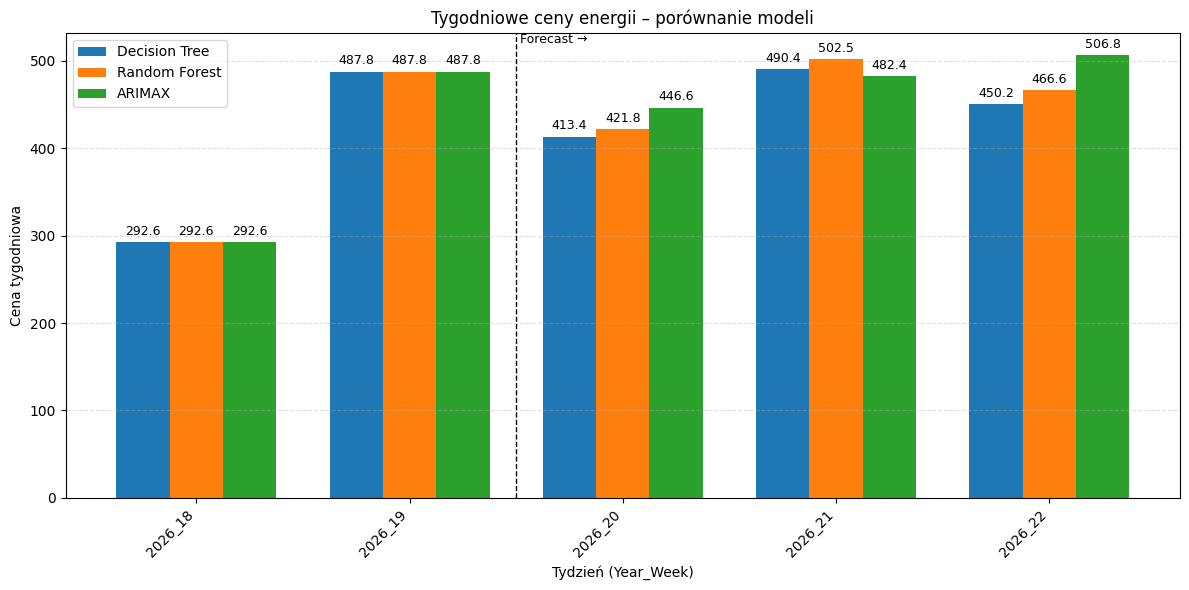

In [ ]:
# ============================================
# MODUŁ 10B: WYKRES SŁUPKOWY – CENY TYGODNIOWE
# (DT / RF / ARIMAX) + ETYKIETY + LINIA HIST/FORECAST
# ============================================

import matplotlib.pyplot as plt
import numpy as np

print("=== GENEROWANIE WYKRESU SŁUPKOWEGO: CENY TYGODNIOWE (z etykietami) ===")

def plot_weekly_prices_bar(weekly_df):
    """
    Wykres słupkowy cen tygodniowych:
    - oś X: YearWeek (chronologicznie)
    - oś Y: cena
    - słupki: DT / RF / ARIMAX
    - etykiety wartości nad słupkami
    - pionowa linia przerywana: granica historia / forecast
    """

    # Kopia bezpieczeństwa
    df = weekly_df.copy().reset_index(drop=True)

    x_labels = df["YearWeek"].tolist()
    x = np.arange(len(x_labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(max(12, len(x_labels) * 0.6), 6))

    bars_dt = ax.bar(x - width, df["DecisionTree"], width, label="Decision Tree")
    bars_rf = ax.bar(x,         df["RandomForest"], width, label="Random Forest")
    bars_ar = ax.bar(x + width, df["ARIMAX"],        width, label="ARIMAX")

    # -------------------------------------------
    # Funkcja pomocnicza: etykiety nad słupkami
    # -------------------------------------------
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            if np.isnan(height):
                continue
            ax.annotate(
                f"{height:.1f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9
            )

    add_labels(bars_dt)
    add_labels(bars_rf)
    add_labels(bars_ar)

    # -------------------------------------------
    # Linia oddzielająca historię od forecastu
    # -------------------------------------------
    if "Type" in df.columns:
        forecast_start_idx = df.index[df["Type"] == "Forecast"]
        if len(forecast_start_idx) > 0:
            first_forecast = forecast_start_idx.min()
            ax.axvline(
                x=first_forecast - 0.5,
                color="black",
                linestyle="--",
                linewidth=1
            )
            ax.text(
                first_forecast - 0.5,
                ax.get_ylim()[1],
                " Forecast →",
                ha="left",
                va="top",
                fontsize=9
            )

    # -------------------------------------------
    # Opisy osi i wygląd
    # -------------------------------------------
    ax.set_xlabel("Tydzień (Year_Week)")
    ax.set_ylabel("Cena tygodniowa")
    ax.set_title("Tygodniowe ceny energii – porównanie modeli")

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha="right")

    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend()

    plt.tight_layout()
    plt.show()


# -------------------------------------------
# UŻYCIE
# -------------------------------------------

plot_weekly_prices_bar(weekly_models_table)


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
from datetime import timedelta

# Set the number of historical days to display on the daily charts
HISTORY_DAYS_DAILY_CHARTS = 10

# Ensure 'Doba' is datetime type for grouping
pk_all = pk.copy()
pk_all['Doba'] = pd.to_datetime(pk_all['Doba'])

# Group by date and calculate the mean for Demand, Wind, PV, and RL
daily_generation_all = pk_all.groupby(pk_all['Doba'].dt.date).agg({
    'Prognozowane zapotrzebowanie sieci [MW]': 'mean',
    'Generacja wiatrowa [MW]': 'mean',
    'Generacja PV [MW]': 'mean',
    'RL': 'mean'
}).reset_index()

# Rename columns for clarity
daily_generation_all.rename(columns={
    'Doba': 'Date',
    'Prognozowane zapotrzebowanie sieci [MW]': 'Daily Average Demand [MW]',
    'Generacja wiatrowa [MW]': 'Daily Average Wind Generation [MW]',
    'Generacja PV [MW]': 'Daily Average PV Generation [MW]',
    'RL': 'Daily Average Residual Load [MW]'
}, inplace=True)

# Convert relevant columns to integer type for display
daily_generation_all_int = daily_generation_all.copy()
for col in ['Daily Average Demand [MW]', 'Daily Average Wind Generation [MW]', 'Daily Average PV Generation [MW]', 'Daily Average Residual Load [MW]']:
    daily_generation_all_int[col] = daily_generation_all_int[col].astype(int)

# Filter historical data based on HISTORY_DAYS_DAILY_CHARTS
last_historical_date = (pd.to_datetime(FORECAST_START) - timedelta(days=1)).date()
hist_start_date = last_historical_date - timedelta(days=HISTORY_DAYS_DAILY_CHARTS - 1)

daily_generation_filtered = daily_generation_all_int[
    (daily_generation_all_int['Date'] >= hist_start_date) &
    (daily_generation_all_int['Date'] <= FORECAST_END)
].copy()

print(f"Daily Averages of Demand, Residual Load, Wind and PV Generation (Historical and Forecast for last {HISTORY_DAYS_DAILY_CHARTS} days of history + forecast):")
display(daily_generation_filtered.head())


NameError: name 'pk' is not defined

In [ ]:
# Create subplots for Demand, Wind, PV, and Residual Load generation
fig = make_subplots(
    rows=4, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.1,
    subplot_titles=(
        'Daily Average Demand [MW]',
        'Daily Average Residual Load [MW]',
        'Daily Average Wind Generation [MW]',
        'Daily Average PV Generation [MW]'
    )
)

# Add traces for Demand
fig.add_trace(go.Bar(x=daily_generation_filtered['Date'], y=daily_generation_filtered['Daily Average Demand [MW]'], name='Demand', marker_color='blue'), row=1, col=1)

# Add traces for Residual Load
fig.add_trace(go.Bar(x=daily_generation_filtered['Date'], y=daily_generation_filtered['Daily Average Residual Load [MW]'], name='Residual Load', marker_color='purple'), row=2, col=1)

# Add traces for Wind Generation
fig.add_trace(go.Bar(x=daily_generation_filtered['Date'], y=daily_generation_filtered['Daily Average Wind Generation [MW]'], name='Wind Generation', marker_color='green'), row=3, col=1)

# Add traces for PV Generation
fig.add_trace(go.Bar(x=daily_generation_filtered['Date'], y=daily_generation_filtered['Daily Average PV Generation [MW]'], name='PV Generation', marker_color='orange'), row=4, col=1)

# Calculate historical averages for the entire df_hist (before filtering for display)
hist_demand_avg = df_hist['Prognozowane zapotrzebowanie sieci [MW]'].mean()
hist_wind_avg = df_hist['Generacja wiatrowa [MW]'].mean()
hist_pv_avg = df_hist['Generacja PV [MW]'].mean()
hist_rl_avg = df_hist['RL'].mean()

# Add horizontal lines for historical averages
fig.add_hline(y=hist_demand_avg, line_dash="dash", line_color="blue", annotation_text=f"Hist. Avg Demand: {hist_demand_avg:.0f} MW", annotation_position="top right", row=1, col=1)
fig.add_hline(y=hist_rl_avg, line_dash="dash", line_color="purple", annotation_text=f"Hist. Avg RL: {hist_rl_avg:.0f} MW", annotation_position="top right", row=2, col=1)
fig.add_hline(y=hist_wind_avg, line_dash="dash", line_color="green", annotation_text=f"Hist. Avg Wind: {hist_wind_avg:.0f} MW", annotation_position="top right", row=3, col=1)
fig.add_hline(y=hist_pv_avg, line_dash="dash", line_color="orange", annotation_text=f"Hist. Avg PV: {hist_pv_avg:.0f} MW", annotation_position="top right", row=4, col=1)

# Add vertical dotted line at FORECAST_START for all subplots
forecast_start_date_str = FORECAST_START.strftime('%Y-%m-%d')
fig.add_vline(
    x=forecast_start_date_str,
    line=dict(color="grey", dash="dot", width=2),
    row=1, col=1
)
fig.add_vline(
    x=forecast_start_date_str,
    line=dict(color="grey", dash="dot", width=2),
    row=2, col=1
)
fig.add_vline(
    x=forecast_start_date_str,
    line=dict(color="grey", dash="dot", width=2),
    row=3, col=1
)
fig.add_vline(
    x=forecast_start_date_str,
    line=dict(color="grey", dash="dot", width=2),
    row=4, col=1
)

# Add annotation for the forecast line (only on the first subplot for readability)
fig.add_annotation(
    x=forecast_start_date_str,
    y=1,
    xref="x",
    yref="paper",
    text="Forecast Start",
    showarrow=False,
    xanchor="left",
    yanchor="bottom",
    font=dict(color="grey"),
    row=1, col=1
)

# Update layout
fig.update_layout(
    title_text='Daily Averages of Demand, Residual Load, Wind and PV Generation (Historical and Forecast)',
    height=1200, # Increased height for 4 subplots
    showlegend=True,
    hovermode='x unified'
)

# Update y-axis titles
fig.update_yaxes(title_text='MW', row=1, col=1)
fig.update_yaxes(title_text='MW', row=2, col=1)
fig.update_yaxes(title_text='MW', row=3, col=1)
fig.update_yaxes(title_text='MW', row=4, col=1)

fig.show()


## Moduł 16.4: Plot - wind, res, etc

In [ ]:
#Wiatr

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# Parametr: ile dni historii pokazać na wykresach
HISTORY_DAYS = 14   # zmień np. na 7, 21, 30 itd.

# --- 1. Dane historyczne i prognozy cen ---

hist_prices = df_hist["Fixing1"].copy()
dt_forecast = df_dt_forecast["Fixing1_DT"].copy()
rf_forecast = df_rf_forecast["Fixing1_RF"].copy()
arimax_forecast = df_arimax_forecast["Fixing1_ARIMAX"].copy()

# Zakres historii (tylko końcówka, żeby nie było za gęsto)
hist_start = hist_prices.index.max() - pd.Timedelta(days=HISTORY_DAYS)
hist_to_plot = hist_prices[hist_prices.index >= hist_start]

# --- 2. Residual Load i Wind Generation: historia + forecast ---

hist_rl = df_hist["RL"].copy()
future_rl = df_forecast["RL"].copy()
rl_all = pd.concat([hist_rl, future_rl]).sort_index()
rl_to_plot = rl_all[rl_all.index >= hist_start]

hist_wind = df_hist["Generacja wiatrowa [MW]"].copy()
future_wind = df_forecast["Generacja wiatrowa [MW]"].copy()
wind_all = pd.concat([hist_wind, future_wind]).sort_index()
wind_to_plot = wind_all[wind_all.index >= hist_start]

# --- 3. Tworzymy figurę z 2 wierszami (wspólna oś X) ---

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    row_heights=[0.6, 0.4],
    subplot_titles=(
        f"Ceny energii: historia ({HISTORY_DAYS} dni) vs prognozy (DT / RF / ARIMAX)",
        "Residual Load (RL)"
    ),
    specs=[[{'secondary_y': True}], [{}]] # Add secondary y-axis to the first subplot
)

# ===== GÓRNY WYKRES: CENY =====

# Historia – linia kropkowana (czarna)
fig.add_trace(
    go.Scatter(
        x=hist_to_plot.index,
        y=hist_to_plot.values,
        mode="lines",
        name=f"Historia ({HISTORY_DAYS} dni)",
        line=dict(color="black", dash="dash"),
    ),
    row=1, col=1, secondary_y=False
)

# Decision Tree – linia ciągła
fig.add_trace(
    go.Scatter(
        x=dt_forecast.index,
        y=dt_forecast.values,
        mode="lines",
        name="Decision Tree",
    ),
    row=1, col=1, secondary_y=False
)

# Random Forest – linia ciągła
fig.add_trace(
    go.Scatter(
        x=rf_forecast.index,
        y=rf_forecast.values,
        mode="lines",
        name="Random Forest",
    ),
    row=1, col=1, secondary_y=False
)

# ARIMAX – linia ciągła
fig.add_trace(
    go.Scatter(
        x=arimax_forecast.index,
        y=arimax_forecast.values,
        mode="lines",
        name="ARIMAX (SARIMAX)",
    ),
    row=1, col=1, secondary_y=False
)

# Wind Generation na drugiej osi Y
fig.add_trace(
    go.Scatter(
        x=wind_to_plot.index,
        y=wind_to_plot.values,
        mode="lines",
        name="Generacja wiatrowa [MW]",
        line=dict(color="purple", dash="dot"),
    ),
    row=1, col=1, secondary_y=True
)

# ===== DOLNY WYKRES: RL =====

fig.add_trace(
    go.Scatter(
        x=rl_to_plot.index,
        y=rl_to_plot.values,
        mode="lines",
        name="Residual Load (RL)",
        line=dict(color="orange"),
    ),
    row=2, col=1
)

# --- 4. Pionowa linia START FORECAST na obu wykresach ---

forecast_start_ts = pd.Timestamp(FORECAST_START)

fig.add_vline(
    x=forecast_start_ts,
    line=dict(color="gray", dash="dot"),
    row=1, col=1
)

fig.add_vline(
    x=forecast_start_ts,
    line=dict(color="gray", dash="dot"),
    row=2, col=1
)

fig.add_annotation(
    x=forecast_start_ts,
    y=1,
    xref="x",
    yref="paper",
    text="START FORECAST",
    showarrow=False,
    xanchor="left",
    yanchor="bottom",
    font=dict(color="gray")
)

# --- 5. Zakres osi X: od początku historii (wg parametru) do końca forecastu ---

x_min = hist_to_plot.index.min()
x_max = arimax_forecast.index.max()
fig.update_xaxes(range=[x_min, x_max], row=1, col=1)
fig.update_xaxes(range=[x_min, x_max], row=2, col=1)

# --- 6. Opisy osi, legenda, layout ---

fig.update_yaxes(title_text="Cena [PLN/MWh]", row=1, col=1, secondary_y=False)
fig.update_yaxes(title_text="Wiatr [MW]", row=1, col=1, secondary_y=True)
fig.update_yaxes(title_text="RL [MW]", row=2, col=1)

fig.update_layout(
    hovermode="x unified",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    height=800,
)

fig.update_xaxes(title_text="Data i godzina", row=2, col=1)

fig.show()


In [ ]:
# ============================================
# MODUŁ 5: FEATURE ENGINEERING
# Tworzenie cech czasowych, lagów, rolling
# zastanów się czy nie do wywalenia
# ============================================

print("=== FEATURE ENGINEERING ===")

df_fe = df.copy()

# --------------------------------------------------------
# 5.1 Cechy kalendarzowe
# --------------------------------------------------------

df_fe["hour"] = df_fe.index.hour
df_fe["weekday"] = df_fe.index.weekday
df_fe["month"] = df_fe.index.month
df_fe["is_weekend"] = (df_fe["weekday"] >= 5).astype(int)

# --------------------------------------------------------
# 5.2 Lags (opóźnienia cen)
# --------------------------------------------------------

df_fe["Fixing1_lag1"] = df_fe["Fixing1"].shift(1)
df_fe["Fixing1_lag24"] = df_fe["Fixing1"].shift(24)

# --------------------------------------------------------
# 5.3 Rolling features
# --------------------------------------------------------

df_fe["Fixing1_roll24_mean"] = df_fe["Fixing1"].rolling(24).mean()
df_fe["Fixing1_roll24_std"]  = df_fe["Fixing1"].rolling(24).std()

# --------------------------------------------------------
# 5.4 Udziały PV i wiatru w zapotrzebowaniu
# --------------------------------------------------------

df_fe["wind_share"] = df_fe["Generacja wiatrowa [MW]"] / df_fe["Prognozowane zapotrzebowanie sieci [MW]"]
df_fe["pv_share"]   = df_fe["Generacja PV [MW]"] / df_fe["Prognozowane zapotrzebowanie sieci [MW]"]

# --------------------------------------------------------
# 5.5 Usuwanie wierszy z brakami (po lagach/rolling)
# --------------------------------------------------------

before = df_fe.shape[0]
df_fe = df_fe.dropna()
after = df_fe.shape[0]

print(f"Usunięto {before - after} wierszy z NaN (laki & rolling).")
print("df_fe przygotowany, wymiar:", df_fe.shape)
print(df_fe.head())


In [ ]:
# ============================================
# WYKRES: HISTORIA + 3 PROGNOZY
# Parametr HISTORY_DAYS określa ile dni historii pokazać
# ============================================

import matplotlib.pyplot as plt
import pandas as pd

# Parametr historii na wykresie
HISTORY_DAYS = 7   # <<–– ZMIEŃ TUTAJ jeśli chcesz (np. 7, 10, 30 itd.)

# 1. Dane historyczne i prognozy
hist_prices = df_hist["Fixing1"].copy()
dt_forecast = df_dt_forecast["Fixing1_DT"].copy()
rf_forecast = df_rf_forecast["Fixing1_RF"].copy()
arimax_forecast = df_arimax_forecast["Fixing1_ARIMAX"].copy()

# 2. Wyliczenie zakresu historii
hist_start = hist_prices.index.max() - pd.Timedelta(days=HISTORY_DAYS)
hist_to_plot = hist_prices[hist_prices.index >= hist_start]

dt_to_plot = dt_forecast.copy()
rf_to_plot = rf_forecast.copy()
arimax_to_plot = arimax_forecast.copy()

# 3. Wykres
plt.figure(figsize=(16, 6))

# Historia – linia kropkowana (czarna)
plt.plot(
    hist_to_plot.index,
    hist_to_plot.values,
    linestyle="--",
    linewidth=1.5,
    color="black",
    label=f"Historia ({HISTORY_DAYS} dni)"
)

# Prognozy – linie ciągłe w różnych kolorach
plt.plot(
    dt_to_plot.index,
    dt_to_plot.values,
    linestyle="-",
    linewidth=1.5,
    color="tab:blue",
    label="Decision Tree"
)

plt.plot(
    rf_to_plot.index,
    rf_to_plot.values,
    linestyle="-",
    linewidth=1.5,
    color="tab:green",
    label="Random Forest"
)

plt.plot(
    arimax_to_plot.index,
    arimax_to_plot.values,
    linestyle="-",
    linewidth=1.5,
    color="tab:red",
    label="ARIMAX (SARIMAX)"
)

# Pionowa linia w miejscu startu prognozy
forecast_start_ts = pd.Timestamp(FORECAST_START)

plt.axvline(
    forecast_start_ts,
    color="grey",
    linestyle=":",
    linewidth=1
)

plt.text(
    forecast_start_ts,
    plt.ylim()[1],
    " START FORECAST",
    rotation=90,
    va="top",
    ha="left",
    color="grey"
)

# Opisy osi, tytuł, legenda
plt.title(f"Ceny energii: historia ({HISTORY_DAYS} dni) vs prognozy (DT / RF / ARIMAX)")
plt.xlabel("Data i godzina")
plt.ylabel("Cena [PLN/MWh]")

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
# ============================================
# INTERAKTYWNY WYKRES: HISTORIA + 3 PROGNOZY
# Plotly
# ============================================

import plotly.graph_objects as go
import pandas as pd

# Parametr: ile dni historii pokazać
HISTORY_DAYS = 7   # zmień np. na 7, 30 itd.

# 1. Dane historyczne i prognozy
hist_prices = df_hist["Fixing1"].copy()
dt_forecast = df_dt_forecast["Fixing1_DT"].copy()
rf_forecast = df_rf_forecast["Fixing1_RF"].copy()
arimax_forecast = df_arimax_forecast["Fixing1_ARIMAX"].copy()

# 2. Zakres historii
hist_start = hist_prices.index.max() - pd.Timedelta(days=HISTORY_DAYS)
hist_to_plot = hist_prices[hist_prices.index >= hist_start]

# 3. Tworzymy figurę
fig = go.Figure()

# Historia – linia kropkowana (czarna)
fig.add_trace(go.Scatter(
    x=hist_to_plot.index,
    y=hist_to_plot.values,
    mode="lines",
    name=f"Historia ({HISTORY_DAYS} dni)",
    line=dict(color="black", dash="dash")
))

# Decision Tree – linia ciągła
fig.add_trace(go.Scatter(
    x=dt_forecast.index,
    y=dt_forecast.values,
    mode="lines",
    name="Decision Tree",
))

# Random Forest – linia ciągła
fig.add_trace(go.Scatter(
    x=rf_forecast.index,
    y=rf_forecast.values,
    mode="lines",
    name="Random Forest",
))

# ARIMAX – linia ciągła
fig.add_trace(go.Scatter(
    x=arimax_forecast.index,
    y=arimax_forecast.values,
    mode="lines",
    name="ARIMAX (SARIMAX)",
))

# 4. Pionowa linia w miejscu startu prognozy
forecast_start_ts = pd.Timestamp(FORECAST_START)

fig.add_vline(
    x=forecast_start_ts,
    line=dict(color="gray", dash="dot"),
)

fig.add_annotation(
    x=forecast_start_ts,
    y=1,
    xref="x",
    yref="paper",
    text="START FORECAST",
    showarrow=False,
    xanchor="left",
    yanchor="bottom",
    font=dict(color="gray")
)

# 5. Ustawienia layoutu
fig.update_layout(
    title=f"Ceny energii: historia ({HISTORY_DAYS} dni) vs prognozy (DT / RF / ARIMAX)",
    xaxis_title="Data i godzina",
    yaxis_title="Cena [PLN/MWh]",
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)

# Opcjonalnie: zakres osi X – historia + cały forecast
x_min = hist_to_plot.index.min()
x_max = arimax_forecast.index.max()
fig.update_xaxes(range=[x_min, x_max])

fig.show()
